# Explore `ds006104` Step by Step

这个 notebook 面向你当前已经下载到本地的 `ds006104` 数据集，目标是按下面的顺序逐步探究：

1. 读取数据集级文档与 BIDS 元数据
2. 清点被试、session、task、文件完整性
3. 汇总事件表，理解刺激与 TMS 设计
4. 读取一个本地可用的原始 EDF，查看通道与时长
5. 基于 `stimulus` 事件切 epoch，做基础 ERP / PSD / 通道统计

说明：你当前这份 datalad/git-annex 数据里，部分 `*_eeg.edf` 目标文件并不在本地，但事件表、channels 和 sidecar JSON 是完整的。所以 notebook 会：

- 先完整跑元数据与事件探索
- 自动寻找一个本地实际存在的 EDF 做 EEG 演示
- 如果某些 EDF 缺失，会给出提示而不是报错中断

In [2]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

DATASET_ROOT = Path("/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad")
OUTPUT_ROOT = Path("outputs") / "ds006104_notebook_outputs"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

assert DATASET_ROOT.exists(), f"Dataset root not found: {DATASET_ROOT}"
print(f"Dataset root: {DATASET_ROOT.resolve()}")
print(f"Notebook outputs: {OUTPUT_ROOT.resolve()}")

Dataset root: /Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad
Notebook outputs: /Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/notebooks/outputs/ds006104_notebook_outputs


## 1. 读取数据集说明文档

先看数据集自己的 `README`、`dataset_description.json`、`participants.tsv`。这一步的目标是先建立整体认知，再进入文件级分析。

In [3]:
readme_text = (DATASET_ROOT / "README").read_text(encoding="utf-8")
dataset_description = json.loads(
    (DATASET_ROOT / "dataset_description.json").read_text(encoding="utf-8")
)
participants = pd.read_csv(DATASET_ROOT / "participants.tsv", sep="\t")
participants_json = json.loads(
    (DATASET_ROOT / "participants.json").read_text(encoding="utf-8")
)
changes_text = (DATASET_ROOT / "CHANGES").read_text(encoding="utf-8")

print("README preview:")
print("-" * 80)
print("\n".join(readme_text.splitlines()[:35]))
print("-" * 80)

summary = {
    "Name": dataset_description.get("Name"),
    "BIDSVersion": dataset_description.get("BIDSVersion"),
    "DatasetType": dataset_description.get("DatasetType"),
    "DatasetDOI": dataset_description.get("DatasetDOI"),
    "License": dataset_description.get("License"),
    "Authors_count": len(dataset_description.get("Authors", [])),
}
print(summary)
print("\nParticipants table shape:", participants.shape)
participants.head()

README preview:
--------------------------------------------------------------------------------
EEG dataset for speech decoding

Dataset Overview
---------------

This dataset contains EEG recordings from a phoneme discrimination task with TMS.
The data were collected during two related studies in 2019 and 2021.

Study 1 (2019, Session 01):
- 8 participants (P01-P08)
- Focus on CV and VC phoneme pairs
- 2 blocks: CV pairs and VC pairs
- TMS targeted to LipM1 (-56, -8, 46) and TongueM1 (-60, -10, 25)

Study 2 (2021, Session 02):
- 16 participants (S01-S16)
- Expanded to include single phonemes and phoneme triplets
- 4 blocks: single phonemes, CV pairs, real words, and pseudowords
- Additional TMS targets included Broca's area (BA 44: -51, 7, 23) and verbal memory region (BA 6: -46, 1, 41)

Task Description
---------------

Participants listened to speech sounds and identified stimuli with a button-press response.
The stimuli included:
1. Single phonemes - Consonants (/b/, /p/, /d/, /t/

,participant_id,original_id,study,study_description
0,sub-P01,P01,Study1,Study 1 (2019): CV and VC phoneme pairs
1,sub-P02,P02,Study1,Study 1 (2019): CV and VC phoneme pairs
2,sub-P03,P03,Study1,Study 1 (2019): CV and VC phoneme pairs
3,sub-P04,P04,Study1,Study 1 (2019): CV and VC phoneme pairs
4,sub-P05,P05,Study1,Study 1 (2019): CV and VC phoneme pairs


In [4]:
display(Markdown("### Dataset Description"))
pd.DataFrame(
    [
        {
            "field": key,
            "value": value if not isinstance(value, list) else "; ".join(map(str, value)),
        }
        for key, value in dataset_description.items()
    ]
).head(20)

### Dataset Description

,field,value
0,Name,EEG dataset for speech decoding
1,BIDSVersion,1.6.0
2,DatasetType,raw
3,Authors,João Pedro Carvalho Moreira; Vinícius Rezende Carvalho; Eduardo Mazoni Andrade Marçal Mendes; Ariah Fallah; Terrence...
4,License,CC0
5,Acknowledgements,This research was funded by the U.S. Russia Foundation through award No. 20-AUG-19-UCLA. The article is an output of...
6,HowToAcknowledge,"Please cite: Moreira et al. ""An open-access EEG dataset for speech decoding: Exploring the role of articulation and ..."
7,DatasetDOI,doi:10.18112/openneuro.ds006104.v1.0.1
8,GeneratedBy,"{'Name': 'MATLAB', 'Version': '9.14.0.2206163 (R2023a)'}"
9,SourceDatasets,


In [5]:
display(Markdown("### Participants Columns Description"))
pd.DataFrame(
    [
        {"column": key, "description": value.get("Description", "")}
        for key, value in participants_json.items()
    ]
)

### Participants Columns Description

,column,description
0,participant_id,Unique participant identifier
1,original_id,Original subject ID from the data collection
2,study,Indicates which study the participant was part of (Study1 or Study2)
3,study_description,Brief description of the study design and focus


In [6]:
print("CHANGES:")
print(changes_text)

CHANGES:
1.0.1 2025-04-08
  - Acknowledgements
1.0.0 2025-04-08
  - Publication
v1.0.0 YYYY-MM-DD
- Initial release of the combined dataset on OpenNeuro



## 2. 清点 BIDS 结构和文件完整性

这里我们把所有与 EEG 分析直接相关的文件扫一遍：

- `*_eeg.edf`
- `*_events.tsv`
- `*_channels.tsv`
- `*_eeg.json`
- `*_coordsystem.json`

同时确认哪些 EDF 在本地是“链接存在但目标文件缺失”的状态。

In [7]:
def parse_bids_entities(path: Path) -> dict[str, str]:
    entities = {}
    stem = path.name
    for suffix in [".edf", ".tsv", ".json"]:
        if stem.endswith(suffix):
            stem = stem[: -len(suffix)]
    for part in stem.split("_"):
        if "-" in part:
            key, value = part.split("-", 1)
            entities[key] = value
    return entities


edf_files = sorted(DATASET_ROOT.rglob("*_eeg.edf"))
events_files = sorted(DATASET_ROOT.rglob("*_events.tsv"))
channels_files = sorted(DATASET_ROOT.rglob("*_channels.tsv"))
eeg_json_files = sorted(DATASET_ROOT.rglob("*_eeg.json"))
coordsystem_files = sorted(DATASET_ROOT.rglob("*_coordsystem.json"))

file_inventory = pd.DataFrame(
    [
        {"kind": "edf", "count": len(edf_files), "existing_targets": sum(p.exists() for p in edf_files)},
        {
            "kind": "events_tsv",
            "count": len(events_files),
            "existing_targets": sum(p.exists() for p in events_files),
        },
        {
            "kind": "channels_tsv",
            "count": len(channels_files),
            "existing_targets": sum(p.exists() for p in channels_files),
        },
        {
            "kind": "eeg_json",
            "count": len(eeg_json_files),
            "existing_targets": sum(p.exists() for p in eeg_json_files),
        },
        {
            "kind": "coordsystem_json",
            "count": len(coordsystem_files),
            "existing_targets": sum(p.exists() for p in coordsystem_files),
        },
    ]
)

file_inventory

,kind,count,existing_targets
0,edf,56,48
1,events_tsv,56,56
2,channels_tsv,56,56
3,eeg_json,56,56
4,coordsystem_json,24,24


In [8]:
broken_edf = [p for p in edf_files if p.is_symlink() and not p.exists()]
existing_edf = [p for p in edf_files if p.exists()]

print(f"Total EDF links: {len(edf_files)}")
print(f"Existing EDF targets: {len(existing_edf)}")
print(f"Broken EDF symlinks: {len(broken_edf)}")
print("\nFirst broken examples:")
for p in broken_edf[:8]:
    print("-", p)

Total EDF links: 56
Existing EDF targets: 48
Broken EDF symlinks: 8

First broken examples:
- /Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P01/ses-01/eeg/sub-P01_ses-01_task-phonemes_eeg.edf
- /Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P02/ses-01/eeg/sub-P02_ses-01_task-phonemes_eeg.edf
- /Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P03/ses-01/eeg/sub-P03_ses-01_task-phonemes_eeg.edf
- /Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P04/ses-01/eeg/sub-P04_ses-01_task-phonemes_eeg.edf
- /Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P05/ses-01/eeg/sub-P05_ses-01_task-phonemes_eeg.edf
- /Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P06/ses-01/eeg/sub-P06_ses-01_task-p

In [11]:
records = []
for p in edf_files:
    ent = parse_bids_entities(p)
    records.append(
        {
            "subject": f"sub-{ent.get('sub')}" if ent.get("sub") else None,
            "session": f"ses-{ent.get('ses')}" if ent.get("ses") else None,
            "task": ent.get("task"),
            "edf_exists": p.exists(),
            "path": str(p),
        }
    )

edf_index = pd.DataFrame(records).sort_values(["subject", "session", "task"]).reset_index(drop=True)
edf_index

,subject,session,task,edf_exists,path
0,sub-P01,ses-01,phonemes,False,/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P01/ses-01/eeg/s...
1,sub-P02,ses-01,phonemes,False,/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P02/ses-01/eeg/s...
2,sub-P03,ses-01,phonemes,False,/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P03/ses-01/eeg/s...
3,sub-P04,ses-01,phonemes,False,/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P04/ses-01/eeg/s...
4,sub-P05,ses-01,phonemes,False,/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P05/ses-01/eeg/s...
5,sub-P06,ses-01,phonemes,False,/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P06/ses-01/eeg/s...
6,sub-P07,ses-01,phonemes,False,/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P07/ses-01/eeg/s...
7,sub-P08,ses-01,phonemes,False,/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P08/ses-01/eeg/s...
8,sub-S01,ses-02,Words,True,/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-S01/ses-02/eeg/s...
9,sub-S01,ses-02,phonemes,True,/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-S01/ses-02/eeg/s...


In [12]:
display(Markdown("### EDF availability by task"))
edf_index.groupby(["session", "task", "edf_exists"]).size().rename("n").reset_index()

### EDF availability by task

,session,task,edf_exists,n
0,ses-01,phonemes,False,8
1,ses-02,Words,True,16
2,ses-02,phonemes,True,16
3,ses-02,singlephoneme,True,16


## 3. 被试、study、task 的整体分布

先确认两期 study 的被试规模，以及它们对应的 task 结构。

In [13]:
participants["study"].value_counts().rename_axis("study").reset_index(name="n_participants")

,study,n_participants
0,Study2,16
1,Study1,8


In [15]:
task_counts = edf_index.groupby(["subject", "session"])["task"].agg(list).reset_index()
task_counts

,subject,session,task
0,sub-P01,ses-01,[phonemes]
1,sub-P02,ses-01,[phonemes]
2,sub-P03,ses-01,[phonemes]
3,sub-P04,ses-01,[phonemes]
4,sub-P05,ses-01,[phonemes]
5,sub-P06,ses-01,[phonemes]
6,sub-P07,ses-01,[phonemes]
7,sub-P08,ses-01,[phonemes]
8,sub-S01,ses-02,"[Words, phonemes, singlephoneme]"
9,sub-S02,ses-02,"[Words, phonemes, singlephoneme]"


In [16]:
summary_by_task = (
    edf_index.groupby("task")
    .agg(
        n_recordings=("path", "size"),
        n_existing_edf=("edf_exists", "sum"),
        n_missing_edf=("edf_exists", lambda s: (~s).sum()),
    )
    .reset_index()
    .sort_values("task")
)
summary_by_task

,task,n_recordings,n_existing_edf,n_missing_edf
0,Words,16,16,0
1,phonemes,24,16,8
2,singlephoneme,16,16,0


## 4. 读取所有事件表并做统一清洗

这里做几件事：

- 读取全部 `events.tsv`
- 补充 `subject / session / task`
- 清洗 `phoneme1/2/3` 中的空字符和 `n/a`
- 区分 `stimulus` 与 `TMS`
- 生成一个统一的 `stimulus_label`

In [17]:
def clean_token(value):
    if pd.isna(value):
        return np.nan
    value = str(value).replace(chr(0), "").strip()
    if value == "" or value.lower() == "n/a":
        return np.nan
    return value


all_events = []
for path in events_files:
    ent = parse_bids_entities(path)
    df = pd.read_csv(path, sep="\t")
    df["subject"] = f"sub-{ent.get('sub')}" if ent.get("sub") else None
    df["session"] = f"ses-{ent.get('ses')}" if ent.get("ses") else None
    df["task"] = ent.get("task")
    df["events_path"] = str(path)
    for col in [
        "phoneme1",
        "phoneme2",
        "phoneme3",
        "category",
        "manner",
        "place",
        "voicing",
        "tms_target",
    ]:
        if col in df.columns:
            df[col] = df[col].map(clean_token)
    all_events.append(df)

all_events = pd.concat(all_events, ignore_index=True)
all_events["trial_type"] = all_events["trial_type"].map(clean_token)
all_events["stimulus_label"] = (
    all_events[["phoneme1", "phoneme2", "phoneme3"]]
    .fillna("")
    .agg("".join, axis=1)
    .replace("", np.nan)
)

print(all_events.shape)
all_events.head()

(29260, 18)


,onset,duration,trial_type,category,manner,phoneme1,phoneme2,place,tms_intensity,tms_target,trial,voicing,subject,session,task,events_path,phoneme3,stimulus_label
0,7.154,0,TMS,alveolar,stop,NaN,NaN,alveolar,110.0,control_lip,1.0,no,sub-P01,ses-01,phonemes,/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P01/ses-01/eeg/s...,NaN,NaN
1,7.204,0,stimulus,NaN,NaN,i,t,NaN,NaN,control_lip,NaN,NaN,sub-P01,ses-01,phonemes,/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P01/ses-01/eeg/s...,NaN,it
2,11.137,0,TMS,bilabial,stop,NaN,NaN,bilabial,110.0,lip,2.0,yes,sub-P01,ses-01,phonemes,/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P01/ses-01/eeg/s...,NaN,NaN
3,11.187,0,stimulus,NaN,NaN,b,o,NaN,NaN,lip,NaN,NaN,sub-P01,ses-01,phonemes,/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P01/ses-01/eeg/s...,NaN,bo
4,15.136,0,TMS,alveolar,stop,NaN,NaN,alveolar,110.0,lip,3.0,no,sub-P01,ses-01,phonemes,/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P01/ses-01/eeg/s...,NaN,NaN


In [18]:
all_events.groupby(["task", "trial_type"]).size().rename("n_events").reset_index()

,task,trial_type,n_events
0,Words,TMS,3693
1,Words,stimulus,3693
2,phonemes,TMS,7582
3,phonemes,stimulus,7582
4,singlephoneme,TMS,3355
5,singlephoneme,stimulus,3355


In [19]:
stim_events = all_events.query("trial_type == 'stimulus'").copy()
tms_events = all_events.query("trial_type == 'TMS'").copy()

print("Stimulus rows:", len(stim_events))
print("TMS rows:", len(tms_events))

Stimulus rows: 14630
TMS rows: 14630


## 5. 任务级事件统计

这一步重点回答几个问题：

- 每个 task 有多少刺激事件？
- 不同 task 的 `tms_target` 怎么分布？
- `stimulus_label` 的词表长什么样？
- `singlephoneme` / `phonemes` / `Words` 的类别字段含义是什么？

In [20]:
stim_events.groupby("task").size().rename("n_stimulus_events").reset_index().sort_values("task")

,task,n_stimulus_events
0,Words,3693
1,phonemes,7582
2,singlephoneme,3355


In [21]:
(
    stim_events.groupby(["task", "tms_target"])
    .size()
    .rename("n")
    .reset_index()
    .sort_values(["task", "n"], ascending=[True, False])
    .head(30)
)

,task,tms_target,n
0,Words,BA06,1360
1,Words,BA44,1101
2,Words,control_BA06,680
3,Words,control_BA44,552
7,phonemes,tongue,2536
6,phonemes,lip,2517
4,phonemes,control_lip,1266
5,phonemes,control_tongue,1263
9,singlephoneme,control_BA06,935
10,singlephoneme,control_BA44,770


In [22]:
(
    stim_events.groupby(["task", "category"])
    .size()
    .rename("n")
    .reset_index()
    .sort_values(["task", "n"], ascending=[True, False])
    .head(30)
)

,task,category,n


In [23]:
for task_name in sorted(stim_events["task"].dropna().unique()):
    labels = stim_events.loc[stim_events["task"] == task_name, "stimulus_label"].dropna()
    print(f"\nTask: {task_name}")
    print(f"Unique stimulus labels: {labels.nunique()}")
    print(labels.value_counts().head(20))


Task: Words
Unique stimulus labels: 17
stimulus_label
be    370
tu    370
di    369
do    248
po    247
bi    247
da    246
te    245
pa    245
bu    245
bo    124
de    124
ta    124
pu    123
pi    122
to    122
ba    122
Name: count, dtype: int64

Task: phonemes
Unique stimulus labels: 40
stimulus_label
te    308
bu    292
po    290
ba    288
ta    287
be    287
de    287
pe    287
di    287
pu    286
pi    286
ti    286
bo    286
to    286
tu    285
do    283
bi    282
pa    282
da    268
du    261
Name: count, dtype: int64

Task: singlephoneme
Unique stimulus labels: 11
stimulus_label
a    305
i    305
e    305
u    305
o    305
s    305
z    305
p    305
b    305
t    305
d    305
Name: count, dtype: int64


In [24]:
trial_summary = (
    all_events.groupby(["subject", "session", "task", "trial_type"])
    .size()
    .rename("n_events")
    .reset_index()
    .pivot_table(
        index=["subject", "session", "task"],
        columns="trial_type",
        values="n_events",
        fill_value=0,
    )
    .reset_index()
)
trial_summary.head(20)

trial_type,subject,session,task,TMS,stimulus
0,sub-P01,ses-01,phonemes,476.0,476.0
1,sub-P02,ses-01,phonemes,479.0,479.0
2,sub-P03,ses-01,phonemes,477.0,477.0
3,sub-P04,ses-01,phonemes,439.0,439.0
4,sub-P05,ses-01,phonemes,461.0,461.0
5,sub-P06,ses-01,phonemes,474.0,474.0
6,sub-P07,ses-01,phonemes,475.0,475.0
7,sub-P08,ses-01,phonemes,461.0,461.0
8,sub-S01,ses-02,Words,120.0,120.0
9,sub-S01,ses-02,phonemes,240.0,240.0


## 6. 查看 sidecar JSON 和 channels 信息

先抽一条 recording，看原始采样率、参考电极、设备和通道布局。

In [25]:
sample_json_path = DATASET_ROOT / "sub-S01" / "ses-02" / "eeg" / "sub-S01_ses-02_task-singlephoneme_eeg.json"
sample_channels_path = DATASET_ROOT / "sub-S01" / "ses-02" / "eeg" / "sub-S01_ses-02_task-singlephoneme_channels.tsv"
sample_coordsystem_path = DATASET_ROOT / "sub-S01" / "ses-02" / "eeg" / "sub-S01_ses-02_coordsystem.json"

sample_eeg_json = json.loads(sample_json_path.read_text(encoding="utf-8"))
sample_channels = pd.read_csv(sample_channels_path, sep="\t")
sample_coordsystem = json.loads(sample_coordsystem_path.read_text(encoding="utf-8"))

pd.DataFrame(
    [
        {
            "field": k,
            "value": v if not isinstance(v, dict) else json.dumps(v, ensure_ascii=False),
        }
        for k, v in sample_eeg_json.items()
    ]
)

,field,value
0,TaskName,single-phoneme
1,TaskDescription,Listening to single phonemes.
2,Instructions,Participants listened to audio clips immersed in white noise and responded with button presses.
3,EEGReference,CPz
4,EEGGround,AFz
5,SamplingFrequency,2000
6,PowerLineFrequency,60
7,SoftwareFilters,n/a
8,HardwareFilters,"{""HighpassFilter"": {""CutoffFrequency"": 0.1}, ""LowpassFilter"": {""CutoffFrequency"": 350}}"
9,EEGPlacementScheme,extended 10-20 system


In [26]:
sample_channels.head(10)

,name,type,units
0,Fp1,EEG,uV
1,Fpz,EEG,uV
2,Fp2,EEG,uV
3,F7,EEG,uV
4,F3,EEG,uV
5,Fz,EEG,uV
6,F4,EEG,uV
7,F8,EEG,uV
8,FC5,EEG,uV
9,FC1,EEG,uV


In [27]:
sample_coordsystem

{'EEGCoordinateSystem': 'Other',
 'EEGCoordinateUnits': 'mm',
 'EEGCoordinateSystemDescription': 'Electrode positions according to the extended 10-20 system'}

## 7. 选择一个本地存在的 EDF 进行原始 EEG 探索

由于你当前本地有 8 个 EDF 还没把 annex 实体拉下来，这里自动选择一个真正存在的 EDF。优先顺序是：

1. `singlephoneme`
2. `phonemes`
3. `Words`

这样可以尽快进入 epoch 和 ERP 分析。

In [28]:
def choose_existing_edf(index_df: pd.DataFrame) -> Path:
    priority = {"singlephoneme": 0, "phonemes": 1, "Words": 2}
    candidates = index_df[index_df["edf_exists"]].copy()
    if candidates.empty:
        raise RuntimeError("No local EDF payloads available.")
    candidates["task_priority"] = candidates["task"].map(lambda x: priority.get(x, 99))
    row = candidates.sort_values(["task_priority", "subject", "session"]).iloc[0]
    return Path(row["path"])


selected_edf = choose_existing_edf(edf_index)
selected_entities = parse_bids_entities(selected_edf)
selected_events_tsv = selected_edf.with_name(selected_edf.name.replace("_eeg.edf", "_events.tsv"))
selected_channels_tsv = selected_edf.with_name(selected_edf.name.replace("_eeg.edf", "_channels.tsv"))
selected_eeg_json = selected_edf.with_name(selected_edf.name.replace("_eeg.edf", "_eeg.json"))

print("Selected EDF:", selected_edf)
print("Selected task:", selected_entities.get("task"))
print("Events TSV exists:", selected_events_tsv.exists())
print("Channels TSV exists:", selected_channels_tsv.exists())
print("EEG JSON exists:", selected_eeg_json.exists())

Selected EDF: /Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-S01/ses-02/eeg/sub-S01_ses-02_task-singlephoneme_eeg.edf
Selected task: singlephoneme
Events TSV exists: True
Channels TSV exists: True
EEG JSON exists: True


In [29]:
raw = mne.io.read_raw_edf(selected_edf, preload=False, verbose=False)
raw

<RawEDF | sub-S01_ses-02_task-singlephoneme_eeg.edf, 62 x 6734000 (3367.0 s), ~51 KiB, data not loaded>

In [30]:
raw_info_summary = {
    "n_channels": raw.info["nchan"],
    "sfreq": raw.info["sfreq"],
    "duration_sec": raw.n_times / raw.info["sfreq"],
    "highpass": raw.info["highpass"],
    "lowpass": raw.info["lowpass"],
    "line_freq": raw.info.get("line_freq"),
    "first_channels": raw.ch_names[:10],
}
raw_info_summary

{'n_channels': 62,
 'sfreq': 2000.0,
 'duration_sec': np.float64(3367.0),
 'highpass': 0.0,
 'lowpass': 1000.0,
 'line_freq': None,
 'first_channels': ['Fp1',
  'Fpz',
  'Fp2',
  'F7',
  'F3',
  'Fz',
  'F4',
  'F8',
  'FC5',
  'FC1']}

In [31]:
selected_events_df = pd.read_csv(selected_events_tsv, sep="\t")
for col in ["phoneme1", "phoneme2", "phoneme3", "category", "manner", "place", "voicing", "tms_target"]:
    if col in selected_events_df.columns:
        selected_events_df[col] = selected_events_df[col].map(clean_token)
selected_events_df["stimulus_label"] = (
    selected_events_df[[c for c in ["phoneme1", "phoneme2", "phoneme3"] if c in selected_events_df.columns]]
    .fillna("")
    .agg("".join, axis=1)
    .replace("", np.nan)
)
selected_events_df.head()

,onset,duration,trial_type,category,manner,phoneme1,phoneme2,phoneme3,place,tms_intensity,tms_target,trial,voicing,stimulus_label
0,336.3660,0,TMS,vowels,NaN,NaN,NaN,NaN,vowels,110.0,control_,1.0,NaN,NaN
1,336.4890,0,stimulus,NaN,NaN,a,NaN,NaN,NaN,NaN,control_,NaN,NaN,a
2,338.3130,0,TMS,vowels,NaN,NaN,NaN,NaN,vowels,110.0,control_,2.0,NaN,NaN
3,338.4260,0,stimulus,NaN,NaN,i,NaN,NaN,NaN,NaN,control_,NaN,NaN,i
4,340.3125,0,TMS,vowels,NaN,NaN,NaN,NaN,vowels,110.0,control_,3.0,NaN,NaN


## 8. 原始 EEG 的基础可视化

先看一小段原始波形，再看通道功率谱。

Reading 0 ... 6733999  =      0.000 ...  3366.999 secs...


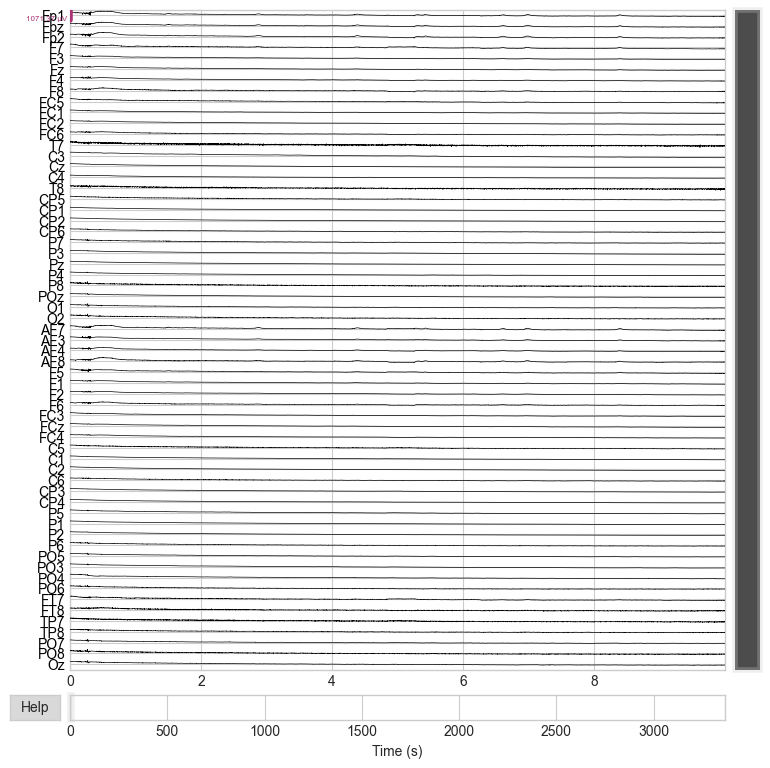

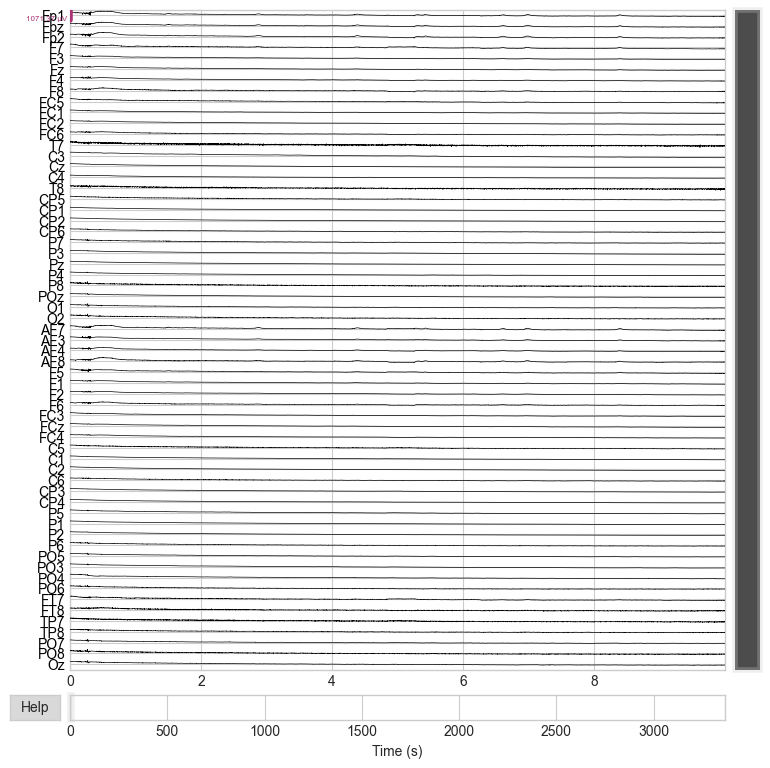

In [34]:
raw_preview = raw.copy().load_data().pick("eeg")
raw_preview.crop(tmin=0, tmax=min(4000, raw_preview.times[-1]))
raw_preview.plot(scalings="auto", n_channels=min(4000, raw_preview.info["nchan"]))

Reading 0 ... 6733999  =      0.000 ...  3366.999 secs...
Effective window size : 1.024 (s)
Plotting power spectral density (dB=True).


/opt/anaconda3/envs/eegvoice/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


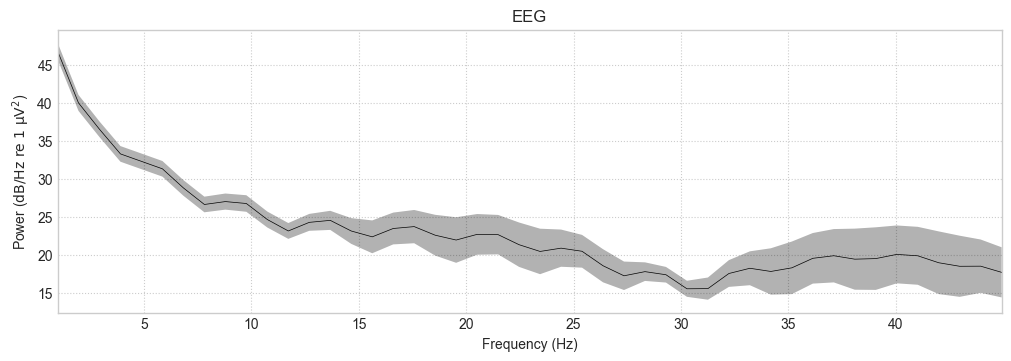

In [35]:
raw_psd = raw.copy().load_data().pick("eeg")
raw_psd.compute_psd(fmin=0.5, fmax=45.0).plot(average=True)

## 9. 把 `stimulus` 事件转成 MNE events

这里我们不依赖 EDF 里内嵌的注释，而是直接用 BIDS `events.tsv` 的 `onset` 来构造事件。这样逻辑更透明，也更适合后续和事件元数据联动。

In [37]:
stim_df = selected_events_df.query("trial_type == 'stimulus'").copy().reset_index(drop=True)
assert not stim_df.empty, "No stimulus rows found for the selected recording."

unique_labels = sorted(stim_df["stimulus_label"].dropna().unique())
event_id = {label: idx + 1 for idx, label in enumerate(unique_labels)}
stim_df["sample"] = (stim_df["onset"] * raw.info["sfreq"]).round().astype(int)
stim_df["event_code"] = stim_df["stimulus_label"].map(event_id)

mne_events = stim_df[["sample", "sample", "event_code"]].copy()
mne_events.iloc[:, 1] = 0
mne_events = mne_events.to_numpy(dtype=int)

print("n stimulus events:", len(stim_df))
print("n unique stimulus labels:", len(unique_labels))
print("First 10 event ids:", list(event_id.items())[:10])
mne_events[:10000]

n stimulus events: 110
n unique stimulus labels: 11
First 10 event ids: [('a', 1), ('b', 2), ('d', 3), ('e', 4), ('i', 5), ('o', 6), ('p', 7), ('s', 8), ('t', 9), ('u', 10)]


array([[ 672978,       0,       1],
       [ 676852,       0,       5],
       [ 680792,       0,       4],
       [ 684787,       0,      10],
       [ 688771,       0,       6],
       [ 692873,       0,       8],
       [ 696790,       0,      11],
       [ 700751,       0,       7],
       [ 704756,       0,       2],
       [ 709122,       0,       9],
       [ 712780,       0,       3],
       [ 716816,       0,       5],
       [ 720801,       0,      10],
       [ 724763,       0,       4],
       [ 728792,       0,       6],
       [ 732841,       0,       1],
       [ 736806,       0,       3],
       [ 740820,       0,       9],
       [ 744741,       0,       2],
       [ 748776,       0,       7],
       [ 752910,       0,      11],
       [ 756865,       0,       8],
       [ 760766,       0,       4],
       [ 764795,       0,       6],
       [ 768766,       0,       5],
       [ 772778,       0,       1],
       [ 776738,       0,      10],
       [ 780757,       0,   

## 10. 预处理一个基础版本并切 epoch

这里采用一个尽量保守、适合初探的流程：

- 选择 EEG 通道
- 1 到 40 Hz band-pass
- 不改参考，先保留数据集原始参考信息
- 以 stimulus onset 为 0 点
- 截取 `-0.2s ~ 0.8s`
- 做 baseline correction

后续你可以再决定是否做重参考、ICA、坏道处理等。

In [38]:
raw_epo = raw.copy().load_data().pick("eeg")
raw_epo.filter(l_freq=1.0, h_freq=40.0, verbose=False)

epochs = mne.Epochs(
    raw_epo,
    mne_events,
    event_id=event_id,
    tmin=-0.2,
    tmax=0.8,
    baseline=(-0.2, 0.0),
    preload=True,
    reject_by_annotation=False,
    verbose=False,
)

epochs

Reading 0 ... 6733999  =      0.000 ...  3366.999 secs...


<Epochs | 110 events (all good), -0.2 – 0.8 s (baseline -0.2 – 0 s), ~102.5 MiB, data loaded,
 'a': 10
 'b': 10
 'd': 10
 'e': 10
 'i': 10
 'o': 10
 'p': 10
 's': 10
 't': 10
 'u': 10
 and 1 more events ...>

In [39]:
epoch_metadata = stim_df.copy()
epoch_metadata = epoch_metadata[
    ["onset", "stimulus_label", "category", "manner", "place", "voicing", "tms_target", "trial"]
]
epochs.metadata = epoch_metadata
print(epochs)
epochs.metadata.head()

Adding metadata with 8 columns
<Epochs | 110 events (all good), -0.2 – 0.8 s (baseline -0.2 – 0 s), ~102.5 MiB, data loaded, with metadata,
 'a': 10
 'b': 10
 'd': 10
 'e': 10
 'i': 10
 'o': 10
 'p': 10
 's': 10
 't': 10
 'u': 10
 and 1 more events ...>


,onset,stimulus_label,category,manner,place,voicing,tms_target,trial
0,336.4890,a,NaN,NaN,NaN,NaN,control_,NaN
1,338.4260,i,NaN,NaN,NaN,NaN,control_,NaN
2,340.3960,e,NaN,NaN,NaN,NaN,control_,NaN
3,342.3935,u,NaN,NaN,NaN,NaN,control_,NaN
4,344.3855,o,NaN,NaN,NaN,NaN,control_,NaN


## 11. 看整体 ERP 和若干条件平均

第一层先看总平均；第二层按数据里最自然的标签切开。对于 `singlephoneme`，通常适合看元音 vs 辅音、voiced vs unvoiced、place/manner。

/var/folders/x9/p1d98gj518326zdc2s5gzn8w0000gn/T/ipykernel_26093/2189536631.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  evoked_all.plot(spatial_colors=True, gfp=True)


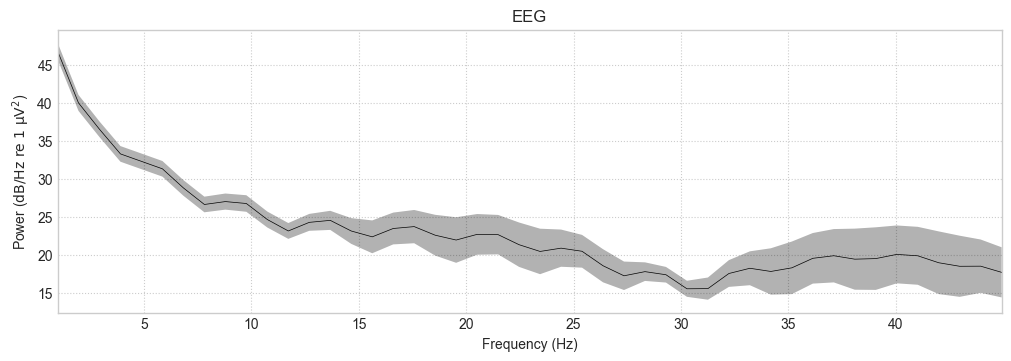

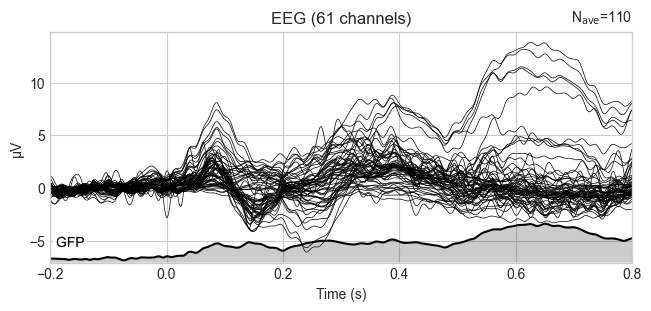

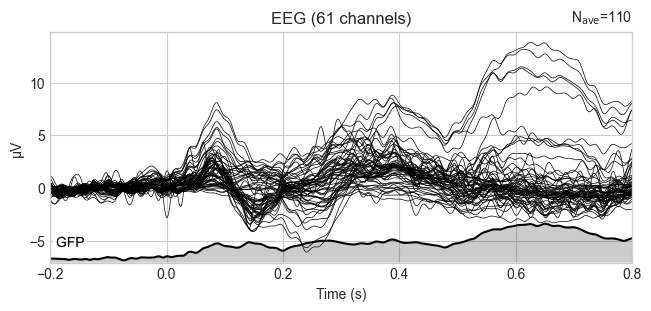

In [40]:
evoked_all = epochs.average()
evoked_all.plot(spatial_colors=True, gfp=True)

In [42]:
if "category" in epochs.metadata.columns and epochs.metadata["category"].notna().any():
    cat_counts = epochs.metadata["category"].value_counts(dropna=True)
    print(cat_counts)
    keep_categories = [c for c, n in cat_counts.items() if n >= 5]
    if keep_categories:
        evokeds = {cat: epochs[epochs.metadata["category"] == cat].average() for cat in keep_categories}
        mne.viz.plot_compare_evokeds(evokeds, combine="mean")

In [43]:
if "voicing" in epochs.metadata.columns and epochs.metadata["voicing"].notna().any():
    voice_counts = epochs.metadata["voicing"].value_counts(dropna=True)
    print(voice_counts)
    keep_voicing = [c for c, n in voice_counts.items() if n >= 5]
    if keep_voicing:
        evokeds = {label: epochs[epochs.metadata["voicing"] == label].average() for label in keep_voicing}
        mne.viz.plot_compare_evokeds(evokeds, combine="mean")

In [44]:
if "place" in epochs.metadata.columns and epochs.metadata["place"].notna().any():
    place_counts = epochs.metadata["place"].value_counts(dropna=True)
    print(place_counts)
    keep_place = [c for c, n in place_counts.items() if n >= 5]
    if keep_place:
        evokeds = {label: epochs[epochs.metadata["place"] == label].average() for label in keep_place}
        mne.viz.plot_compare_evokeds(evokeds, combine="mean")

## 12. 看几个代表时间窗的 topomap

这一步帮助我们快速判断刺激后不同时段的空间分布。

In [46]:
print(evoked_all.get_montage())
print(evoked_all.info["dig"])

None
None


In [47]:
# times = np.array([0.05, 0.10, 0.15, 0.20, 0.30, 0.40])
# evoked_all.plot_topomap(times=times, ch_type="eeg")

## 13. 单试次幅度统计

这里给出一个非常适合初探的 summary：

- 每个 epoch 在若干时间窗里的全脑平均绝对振幅
- 再按条件做 boxplot / 均值比较

In [48]:
epoch_data = epochs.get_data(copy=True)
times = epochs.times

windows = {
    "pre_baseline": (-0.2, 0.0),
    "early_50_150ms": (0.05, 0.15),
    "mid_150_300ms": (0.15, 0.30),
    "late_300_500ms": (0.30, 0.50),
}

summary_df = epochs.metadata.copy()
for name, (t0, t1) in windows.items():
    mask = (times >= t0) & (times <= t1)
    summary_df[name] = np.mean(np.abs(epoch_data[:, :, mask]), axis=(1, 2))

summary_df.head()

,onset,stimulus_label,category,manner,place,voicing,tms_target,trial,pre_baseline,early_50_150ms,mid_150_300ms,late_300_500ms
0,336.4890,a,NaN,NaN,NaN,NaN,control_,NaN,0.000004,0.000008,0.000005,0.000005
1,338.4260,i,NaN,NaN,NaN,NaN,control_,NaN,0.000004,0.000007,0.000007,0.000010
2,340.3960,e,NaN,NaN,NaN,NaN,control_,NaN,0.000002,0.000004,0.000006,0.000006
3,342.3935,u,NaN,NaN,NaN,NaN,control_,NaN,0.000002,0.000005,0.000007,0.000008
4,344.3855,o,NaN,NaN,NaN,NaN,control_,NaN,0.000004,0.000003,0.000006,0.000011


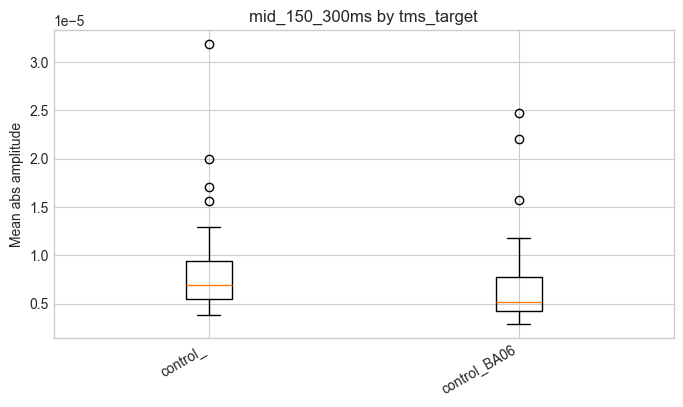

In [49]:
plot_cols = [
    c
    for c in ["category", "voicing", "place", "tms_target"]
    if c in summary_df.columns and summary_df[c].notna().any()
]
metric = "mid_150_300ms"

for col in plot_cols[:3]:
    fig, ax = plt.subplots(figsize=(8, 4))
    grouped = summary_df.dropna(subset=[col]).groupby(col)[metric]
    labels = []
    values = []
    for label, vals in grouped:
        if len(vals) >= 5:
            labels.append(label)
            values.append(vals.values)
    if values:
        ax.boxplot(values, tick_labels=labels)
        ax.set_title(f"{metric} by {col}")
        ax.set_ylabel("Mean abs amplitude")
        plt.xticks(rotation=30, ha="right")
        plt.show()

## 14. 生成 recording 级元数据总表

这是后续你做系统性分析时最实用的中间结果之一：把每个 recording 的关键 sidecar 信息、事件数量、EDF 是否在本地等信息统一成一张表。

In [51]:
recording_rows = []
for edf_path in edf_files:
    ent = parse_bids_entities(edf_path)
    subj = f"sub-{ent.get('sub')}"
    sess = f"ses-{ent.get('ses')}"
    task = ent.get("task")
    eeg_json_path = edf_path.with_name(edf_path.name.replace("_eeg.edf", "_eeg.json"))
    events_path = edf_path.with_name(edf_path.name.replace("_eeg.edf", "_events.tsv"))
    channels_path = edf_path.with_name(edf_path.name.replace("_eeg.edf", "_channels.tsv"))

    eeg_meta = json.loads(eeg_json_path.read_text(encoding="utf-8")) if eeg_json_path.exists() else {}
    ev = pd.read_csv(events_path, sep="\t") if events_path.exists() else pd.DataFrame()
    stim = ev[ev["trial_type"] == "stimulus"] if "trial_type" in ev.columns else pd.DataFrame()
    tms = ev[ev["trial_type"] == "TMS"] if "trial_type" in ev.columns else pd.DataFrame()
    ch = pd.read_csv(channels_path, sep="\t") if channels_path.exists() else pd.DataFrame()

    unique_targets = ""
    if not stim.empty and "tms_target" in stim.columns:
        cleaned_targets = sorted({str(x) for x in stim["tms_target"].dropna().unique()})
        unique_targets = ", ".join(cleaned_targets)

    recording_rows.append(
        {
            "subject": subj,
            "session": sess,
            "task": task,
            "edf_exists_locally": edf_path.exists(),
            "sampling_frequency": eeg_meta.get("SamplingFrequency"),
            "reference": eeg_meta.get("EEGReference"),
            "ground": eeg_meta.get("EEGGround"),
            "cap_model": eeg_meta.get("CapManufacturersModelName"),
            "device_model": eeg_meta.get("ManufacturersModelName"),
            "n_channels_tsv": len(ch),
            "n_stimulus_events": len(stim),
            "n_tms_events": len(tms),
            "unique_tms_targets": unique_targets,
            "events_path": str(events_path),
            "edf_path": str(edf_path),
        }
    )

recording_summary = (
    pd.DataFrame(recording_rows).sort_values(["subject", "session", "task"]).reset_index(drop=True)
)
recording_summary

,subject,session,task,edf_exists_locally,sampling_frequency,reference,ground,cap_model,device_model,n_channels_tsv,n_stimulus_events,n_tms_events,unique_tms_targets,events_path,edf_path
0,sub-P01,ses-01,phonemes,False,2000,CPz,AFz,WaveGuard 64-channel EEG cap,eego mylab system,61,476,476,"control_lip, control_tongue, lip, tongue",/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P01/ses-01/eeg/s...,/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P01/ses-01/eeg/s...
1,sub-P02,ses-01,phonemes,False,2000,CPz,AFz,WaveGuard 64-channel EEG cap,eego mylab system,61,479,479,"control_lip, control_tongue, lip, tongue",/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P02/ses-01/eeg/s...,/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P02/ses-01/eeg/s...
2,sub-P03,ses-01,phonemes,False,2000,CPz,AFz,WaveGuard 64-channel EEG cap,eego mylab system,61,477,477,"control_lip, control_tongue, lip, tongue",/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P03/ses-01/eeg/s...,/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P03/ses-01/eeg/s...
3,sub-P04,ses-01,phonemes,False,2000,CPz,AFz,WaveGuard 64-channel EEG cap,eego mylab system,61,439,439,"control_lip, control_tongue, lip, tongue",/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P04/ses-01/eeg/s...,/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P04/ses-01/eeg/s...
4,sub-P05,ses-01,phonemes,False,2000,CPz,AFz,WaveGuard 64-channel EEG cap,eego mylab system,61,461,461,"control_lip, control_tongue, lip, tongue",/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P05/ses-01/eeg/s...,/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P05/ses-01/eeg/s...
5,sub-P06,ses-01,phonemes,False,2000,CPz,AFz,WaveGuard 64-channel EEG cap,eego mylab system,61,474,474,"control_lip, control_tongue, lip, tongue",/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P06/ses-01/eeg/s...,/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P06/ses-01/eeg/s...
6,sub-P07,ses-01,phonemes,False,2000,CPz,AFz,WaveGuard 64-channel EEG cap,eego mylab system,61,475,475,"control_lip, control_tongue, lip, tongue",/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P07/ses-01/eeg/s...,/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P07/ses-01/eeg/s...
7,sub-P08,ses-01,phonemes,False,2000,CPz,AFz,WaveGuard 64-channel EEG cap,eego mylab system,61,461,461,"control_lip, control_tongue, lip, tongue",/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P08/ses-01/eeg/s...,/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-P08/ses-01/eeg/s...
8,sub-S01,ses-02,Words,True,2000,CPz,AFz,WaveGuard 64-channel EEG cap,eego mylab system,61,120,120,"BA06, control_BA06",/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-S01/ses-02/eeg/s...,/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-S01/ses-02/eeg/s...
9,sub-S01,ses-02,phonemes,True,2000,CPz,AFz,WaveGuard 64-channel EEG cap,eego mylab system,61,240,240,"control_lip, control_tongue, lip, tongue",/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-S01/ses-02/eeg/s...,/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-S

In [52]:
summary_csv = OUTPUT_ROOT / "ds006104_recording_summary.csv"
recording_summary.to_csv(summary_csv, index=False)
print(f"Saved: {summary_csv.resolve()}")

Saved: /Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/notebooks/outputs/ds006104_notebook_outputs/ds006104_recording_summary.csv


## 15. 下一步建议

如果你准备继续深入，我建议按这个顺序走：

1. 先补齐缺失的 8 个 EDF annex 对象，这样 Study 1 的 `sub-P01` 到 `sub-P08` 也能进原始 EEG 分析
2. 对每个 task 分开做 epoching，因为 `singlephoneme / phonemes / Words` 的刺激结构不同
3. 明确要预测的标签层级：
   - `singlephoneme`: 单音素类别、元音/辅音、voicing、place、manner
   - `phonemes`: CV / VC 组合、共发音结构、TMS target
   - `Words`: real vs nonce、CVC 序列、TMS target
4. 再进入机器学习前，先做坏道、重参考、ICA/伪迹检查和 trial-level QC

如果你愿意，下一步我可以继续直接给你补：

- 一个 `scripts/` 下可复用的 `.py` 版分析脚本
- 一个批量遍历所有 recording 的 ERP/PSD 导出脚本
- 一个面向解码任务的数据准备 notebook

In [55]:
from pathlib import Path
import zipfile

jasp_path = Path(
    "/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/OSF-Files/Study 2/2021_Study2_behavioral/2021_behavioral_noSham_phoneme.jasp"
)

# 解压到 .jasp 当前所在目录下的一个新文件夹
extract_dir = jasp_path.parent / f"{jasp_path.stem}_unzipped"

extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(jasp_path, "r") as z:
    z.extractall(extract_dir)

print("解压完成：", extract_dir)

print("\n解压后的文件：")
for p in extract_dir.rglob("*"):
    if p.is_file():
        print(p.relative_to(extract_dir))

解压完成： /Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/OSF-Files/Study 2/2021_Study2_behavioral/2021_behavioral_noSham_phoneme_unzipped

解压后的文件：
index.html
analyses.json
xdata.json
metadata.json
data.bin
META-INF/MANIFEST.MF
resources/0/jaspResultsFinishedWriting.txt
resources/0/jaspResults.json
resources/0/state
resources/0/_30_t187185657.png
resources/1/jaspResultsFinishedWriting.txt
resources/1/jaspResults.json
resources/1/state


In [57]:
from pathlib import Path
import mne

fdt_path = Path(
    "/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/OSF-Files/Analysis - Speech Decoding Dataset/S01/Control/S01_4_set_trials.fdt"
)

set_path = fdt_path.with_suffix(".set")

print("SET exists:", set_path.exists())
print("FDT exists:", fdt_path.exists())

# 注意：这里不要写 preload=True
epochs = mne.io.read_epochs_eeglab(
    set_path,
    verbose=True
)

print(epochs)
print("Data shape:", epochs.get_data().shape)
print("Sampling rate:", epochs.info["sfreq"])
print("Time range:", epochs.times[0], "to", epochs.times[-1])
print("Number of channels:", len(epochs.ch_names))
print("First 10 channels:", epochs.ch_names[:10])
print("Event IDs:", epochs.event_id)

SET exists: True
FDT exists: True
Extracting parameters from /Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/OSF-Files/Analysis - Speech Decoding Dataset/S01/Control/S01_4_set_trials.set...
Not setting metadata
80 matching events found
No baseline correction applied
0 projection items activated
Ready.
<EpochsEEGLAB | 80 events (all good), 0 – 0.996 s (baseline off), ~9.6 MiB, data loaded,
 'stim_1_f/stim_2_f': 80>
Data shape: (80, 61, 256)
Sampling rate: 256.0
Time range: 0.0 to 0.99609375
Number of channels: 61
First 10 channels: ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1']
Event IDs: {'stim_1_f/stim_2_f': 1}


/var/folders/x9/p1d98gj518326zdc2s5gzn8w0000gn/T/ipykernel_26093/2078326044.py:14: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(


In [58]:
from pathlib import Path
import mne

fdt_path = Path(
    "/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/OSF-Files/Study 2/EEG_Data_Processing/TMS_on_Lip_Targuet/S01_4_set_trials.fdt"
)

set_path = fdt_path.with_suffix(".set")

print("SET exists:", set_path.exists())
print("FDT exists:", fdt_path.exists())

# 注意：这里不要写 preload=True
epochs = mne.io.read_epochs_eeglab(
    set_path,
    verbose=True
)

print(epochs)
print("Data shape:", epochs.get_data().shape)
print("Sampling rate:", epochs.info["sfreq"])
print("Time range:", epochs.times[0], "to", epochs.times[-1])
print("Number of channels:", len(epochs.ch_names))
print("First 10 channels:", epochs.ch_names[:10])
print("Event IDs:", epochs.event_id)

SET exists: True
FDT exists: True
Extracting parameters from /Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/OSF-Files/Study 2/EEG_Data_Processing/TMS_on_Lip_Targuet/S01_4_set_trials.set...
Not setting metadata
80 matching events found
No baseline correction applied
0 projection items activated
Ready.
<EpochsEEGLAB | 80 events (all good), 0 – 0.996 s (baseline off), ~9.6 MiB, data loaded,
 'stim_1_tl/stim_2_tl/stim_1_tl': 79
 'stim_1_tl/stim_2_tl': 1>
Data shape: (80, 61, 256)
Sampling rate: 256.0
Time range: 0.0 to 0.99609375
Number of channels: 61
First 10 channels: ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1']
Event IDs: {'stim_1_tl/stim_2_tl/stim_1_tl': 1, 'stim_1_tl/stim_2_tl': 2}


/var/folders/x9/p1d98gj518326zdc2s5gzn8w0000gn/T/ipykernel_26093/2636882601.py:14: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(


In [60]:
import json
from pathlib import Path
import pandas as pd

bin_path = Path(
    "/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/OSF-Files/Study 2/2021_Study2_behavioral/2021_behavioral_noSham_phoneme_unzipped/data.bin"
)

unzipped_dir = bin_path.parent

for json_name in ["metadata.json", "analyses.json", "index.json"]:
    p = unzipped_dir / json_name

    if p.exists():
        print("\n" + "=" * 80)
        print("JSON file:", p.name)

        with open(p, "r", encoding="utf-8", errors="replace") as f:
            data = json.load(f)

        print("Top-level keys:", list(data.keys()) if isinstance(data, dict) else type(data))

        # 简单展开看前几层
        if isinstance(data, dict):
            for k, v in data.items():
                print(f"\nKEY: {k}")
                print("TYPE:", type(v))
                if isinstance(v, list):
                    print("LEN:", len(v))
                    print("FIRST:", v[:2])
                elif isinstance(v, dict):
                    print("SUBKEYS:", list(v.keys())[:20])
                else:
                    print("VALUE:", str(v)[:300])


JSON file: metadata.json
Top-level keys: ['computedColumns', 'dataFilePath', 'dataFileReadOnly', 'dataFileTimestamp', 'dataSet', 'emptyValues', 'filterConstructorJSON', 'filterData']

KEY: computedColumns
TYPE: <class 'list'>
LEN: 0
FIRST: []

KEY: dataFilePath
TYPE: <class 'str'>
VALUE: D:/PLT-38819 Data/1.Speech Decoding/0.Paper_PicsStats/OSF_uploads/Updated_2019_cv_cat/Alveolar/2021_behavioral_noSham_phoneme.csv

KEY: dataFileReadOnly
TYPE: <class 'bool'>
VALUE: False

KEY: dataFileTimestamp
TYPE: <class 'int'>
VALUE: 1662710315

KEY: dataSet
TYPE: <class 'dict'>
SUBKEYS: ['columnCount', 'emptyValuesMap', 'fields', 'filterVector', 'rowCount']

KEY: emptyValues
TYPE: <class 'list'>
LEN: 4
FIRST: ['NaN', 'nan']

KEY: filterConstructorJSON
TYPE: <class 'str'>
VALUE: {"formulas":[]}

KEY: filterData
TYPE: <class 'str'>
VALUE: # Add filters using R syntax here, see question mark for help.

generatedFilter # by default: pass the non-R filter(s)

JSON file: analyses.json
Top-level keys: [

In [61]:
from pathlib import Path
import mne

edf_path = Path(
    "/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-S13/ses-02/eeg/sub-S13_ses-02_task-singlephoneme_eeg.edf"
)

raw = mne.io.read_raw_edf(
    edf_path,
    preload=False,
    verbose=True
)

print(raw)
print("Sampling rate:", raw.info["sfreq"])
print("Duration seconds:", raw.n_times / raw.info["sfreq"])
print("Number of channels:", len(raw.ch_names))

print("\nChannel names:")
for ch in raw.ch_names:
    print(ch)

Extracting EDF parameters from /Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/raw/openneuro/ds006104_datalad/sub-S13/ses-02/eeg/sub-S13_ses-02_task-singlephoneme_eeg.edf...
Setting channel info structure...
Creating raw.info structure...
<RawEDF | sub-S13_ses-02_task-singlephoneme_eeg.edf, 62 x 9226000 (4613.0 s), ~51 KiB, data not loaded>
Sampling rate: 2000.0
Duration seconds: 4613.0
Number of channels: 62

Channel names:
Fp1
Fpz
Fp2
F7
F3
Fz
F4
F8
FC5
FC1
FC2
FC6
T7
C3
Cz
C4
T8
CP5
CP1
CP2
CP6
P7
P3
Pz
P4
P8
POz
O1
O2
AF7
AF3
AF4
AF8
F5
F1
F2
F6
FC3
FCz
FC4
C5
C1
C2
C6
CP3
CP4
P5
P1
P2
P6
PO5
PO3
PO4
PO6
FT7
FT8
TP7
TP8
PO7
PO8
Oz
Status
